# Task 3 — Model Explainability (SHAP)

We interpret the **selected XGBoost models** from Task 2 and turn the insights
into business recommendations.

Pipeline of work:

1. **Built-in feature importance** — XGBoost gain importance, top 10.
2. **SHAP global analysis** — beeswarm summary + mean(|SHAP|) bar.
3. **SHAP local analysis** — force plots for a true positive, a false
   positive and a false negative.
4. **Interpretation** — SHAP vs built-in, top-5 drivers, surprising findings.
5. **Business recommendations** tied to specific SHAP insights.

All heavy lifting lives in `src/explainability.py` so the notebook, the saved
figures (`reports/figures/`) and the report stay perfectly in sync.

> Prerequisites: run Task 1 (`python -m src.pipeline`) and Task 2
> (`notebooks/02_model_building.ipynb`) so the processed data and the
> `models/xgb_*.joblib` files exist.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import Image, display

from src import config, explainability

pd.set_option("display.max_columns", 50)
MODELS = config.PROJECT_ROOT / "models"
FIG = config.FIGURES_DIR

## 1. Load processed data

The two datasets are **separate modeling problems** with different feature
structures, so we explain each independently.

In [2]:
fraud = pd.read_csv(config.PROCESSED_DIR / "fraud_processed.csv")
cc = pd.read_csv(config.PROCESSED_DIR / "creditcard_processed.csv")
print("e-commerce:", fraud.shape, "| credit card:", cc.shape)

e-commerce: (151112, 18) | credit card: (283726, 31)


## 2. E-commerce model (`Fraud_Data`)

`explain_dataset` rebuilds the **exact** Task-2 stratified test split, then
computes built-in importance, SHAP on a 5,000-row test sample, and force plots
for the most confident TP / FP / FN. It saves every figure to
`reports/figures/` and returns the importance tables.

In [3]:
res_ec = explainability.explain_dataset(
    fraud, target="class",
    model_path=MODELS / "xgb_ecommerce.joblib", name="ecommerce",
)


ecommerce


Saved -> reports/figures/importance_builtin_ecommerce.png

Built-in importance (top 10):
                  feature  importance
         device_txn_count    0.555106
        time_since_signup    0.038157
            source_Direct    0.017115
            device_shared    0.016221
country_Korea Republic of    0.014989
           browser_Chrome    0.014646
            browser_Opera    0.014542
    country_United States    0.014394
               browser_IE    0.014344
               source_SEO    0.014286


Saved -> reports/figures/shap_summary_ecommerce.png


Saved -> reports/figures/shap_bar_ecommerce.png

SHAP importance (top 10, mean |SHAP|):
           feature  mean_abs_shap
  device_txn_count       1.121789
 time_since_signup       0.673121
    purchase_value       0.172455
               age       0.140674
     purchase_hour       0.127538
purchase_dayofweek       0.082605
     source_Direct       0.039944
    browser_Chrome       0.033783
             sex_F       0.031462
        source_SEO       0.031333


Saved -> reports/figures/shap_force_ecommerce_true_positive.png


Saved -> reports/figures/shap_force_ecommerce_false_positive.png


Saved -> reports/figures/shap_force_ecommerce_false_negative.png

Explained individual predictions:
    true_positive: prob=1.0000 (true=1, pred=1)
   false_positive: prob=0.9999 (true=0, pred=1)
   false_negative: prob=0.0004 (true=1, pred=0)


### 2.1 Built-in feature importance (top 10)

,feature,importance
0,device_txn_count,0.555106
1,time_since_signup,0.038157
2,source_Direct,0.017115
3,device_shared,0.016221
4,country_Korea Republic of,0.014989
5,browser_Chrome,0.014646
6,browser_Opera,0.014542
7,country_United States,0.014394
8,browser_IE,0.014344
9,source_SEO,0.014286


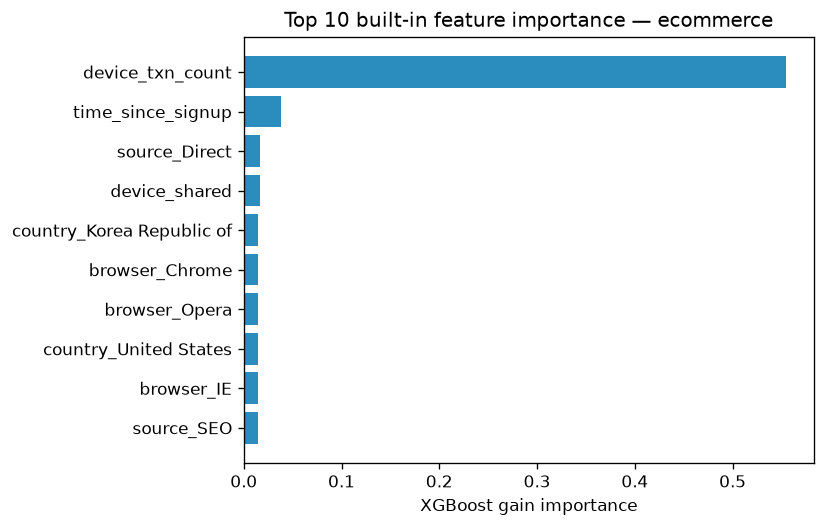

In [4]:
display(res_ec.builtin_top)
display(Image(filename=str(FIG / "importance_builtin_ecommerce.png")))

### 2.2 SHAP global importance

The **beeswarm** shows magnitude *and* direction: each dot is a transaction,
colour is the (scaled) feature value, x-position is the push toward fraud
(right) or legit (left). The **bar** is mean(|SHAP|), directly comparable to
the built-in importance above.

,feature,mean_abs_shap
0,device_txn_count,1.121789
1,time_since_signup,0.673121
2,purchase_value,0.172455
3,age,0.140674
4,purchase_hour,0.127538
5,purchase_dayofweek,0.082605
6,source_Direct,0.039944
7,browser_Chrome,0.033783
8,sex_F,0.031462
9,source_SEO,0.031333


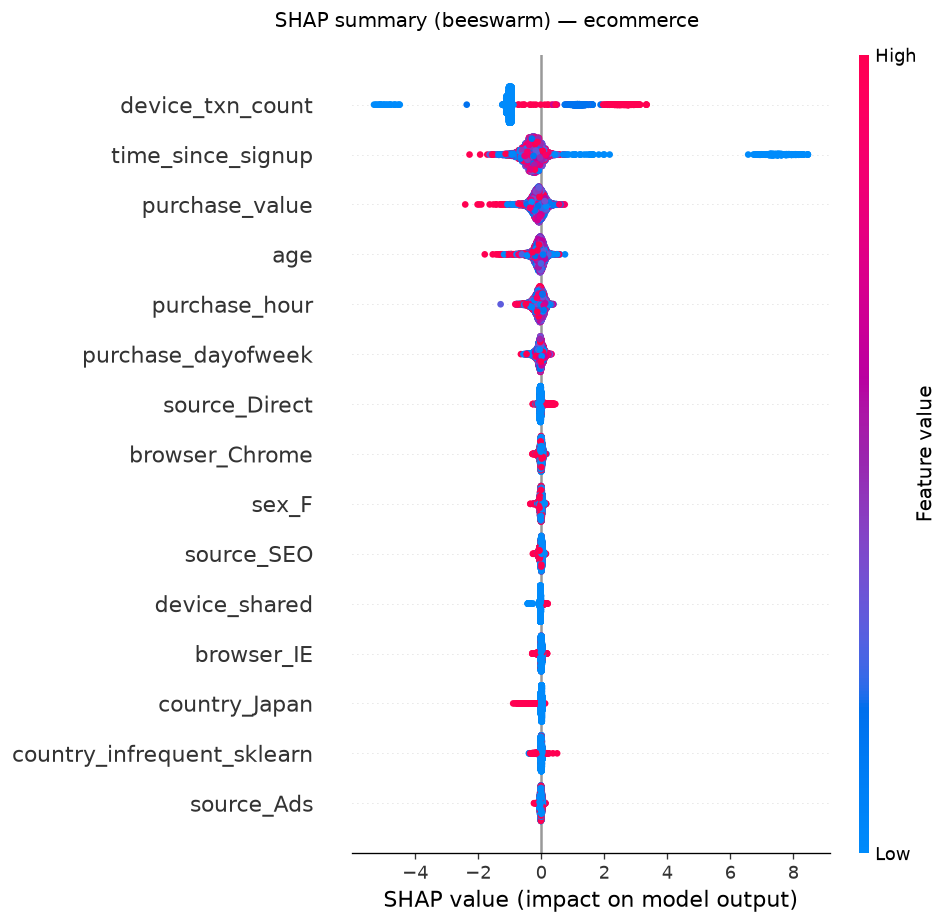

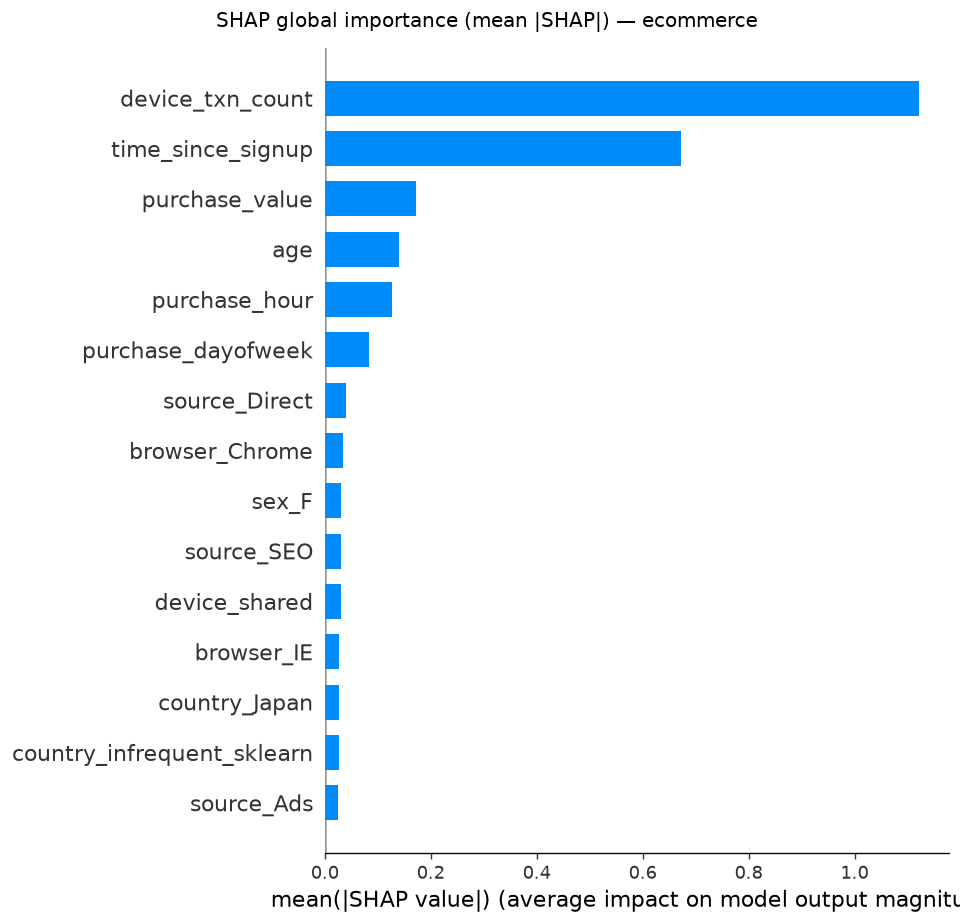

In [5]:
display(res_ec.shap_top)
display(Image(filename=str(FIG / "shap_summary_ecommerce.png")))
display(Image(filename=str(FIG / "shap_bar_ecommerce.png")))

### 2.3 SHAP force plots — individual predictions

Red features push the prediction toward **fraud**, blue toward **legit**.
Feature values are in scaled (StandardScaler) space, so e.g. a negative
`time_since_signup` means *shorter than average* time between signup and
purchase.

{'true_positive': {'true_label': 1, 'pred_label': 1, 'fraud_probability': 0.9999918937683105}, 'false_positive': {'true_label': 0, 'pred_label': 1, 'fraud_probability': 0.9998997449874878}, 'false_negative': {'true_label': 1, 'pred_label': 0, 'fraud_probability': 0.0004320400767028332}}

true_positive


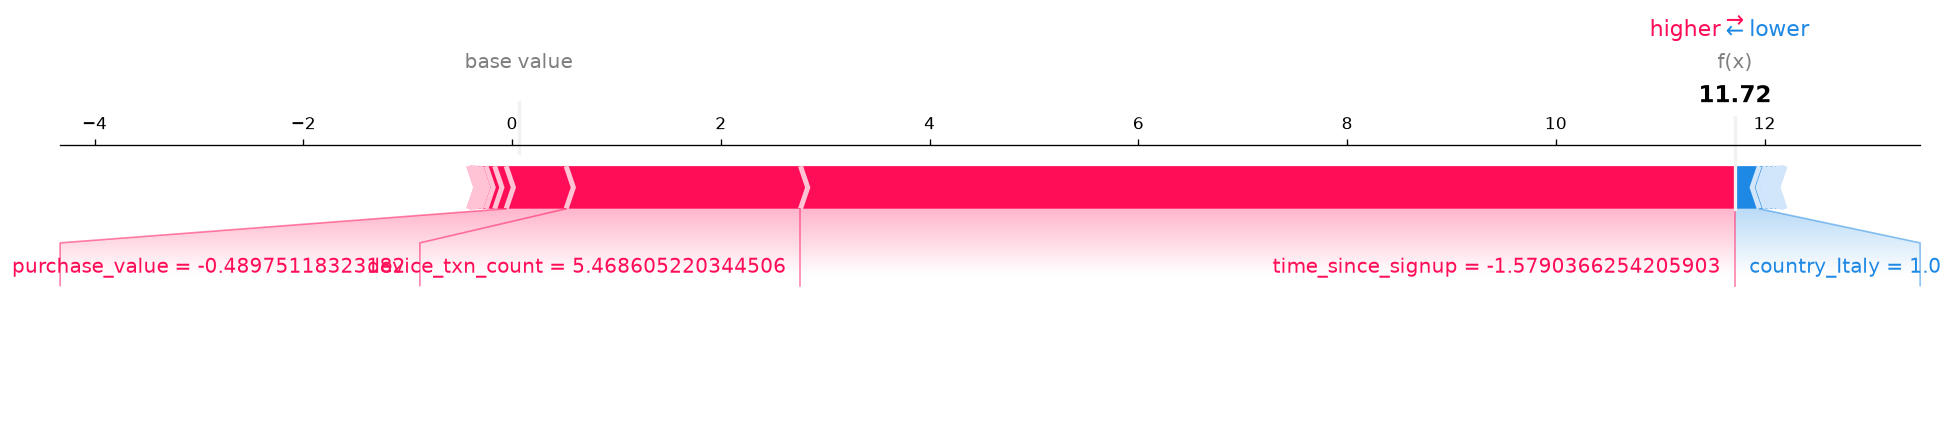


false_positive


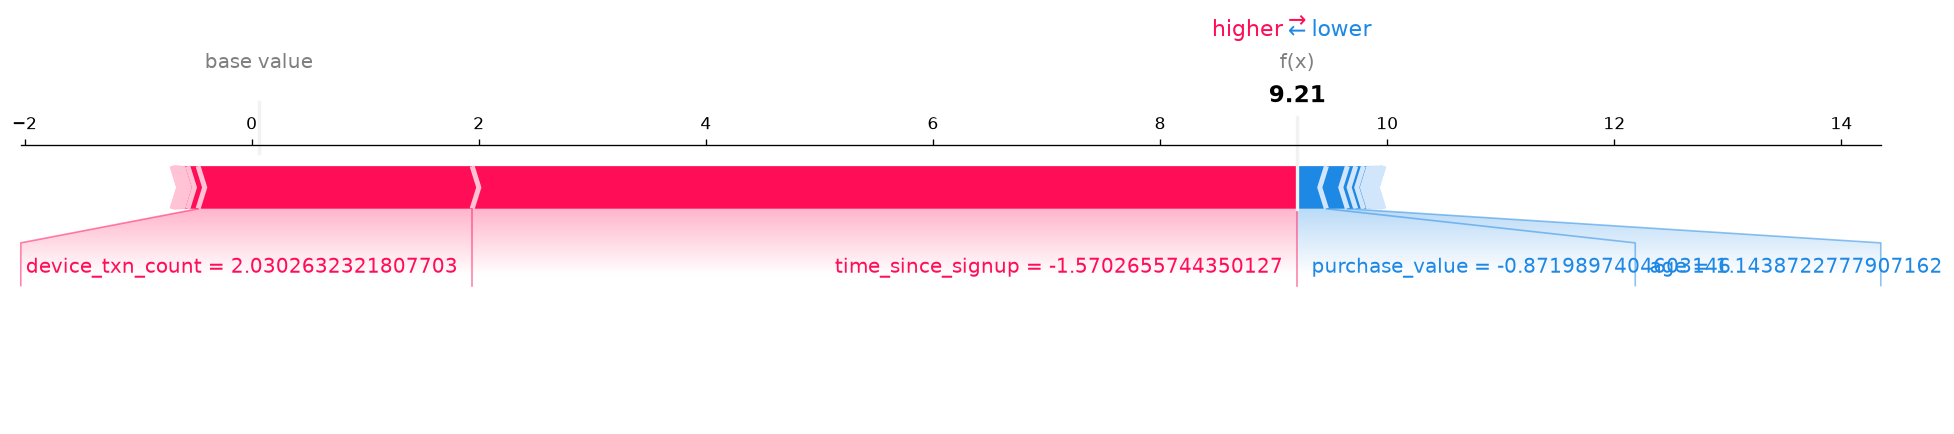


false_negative


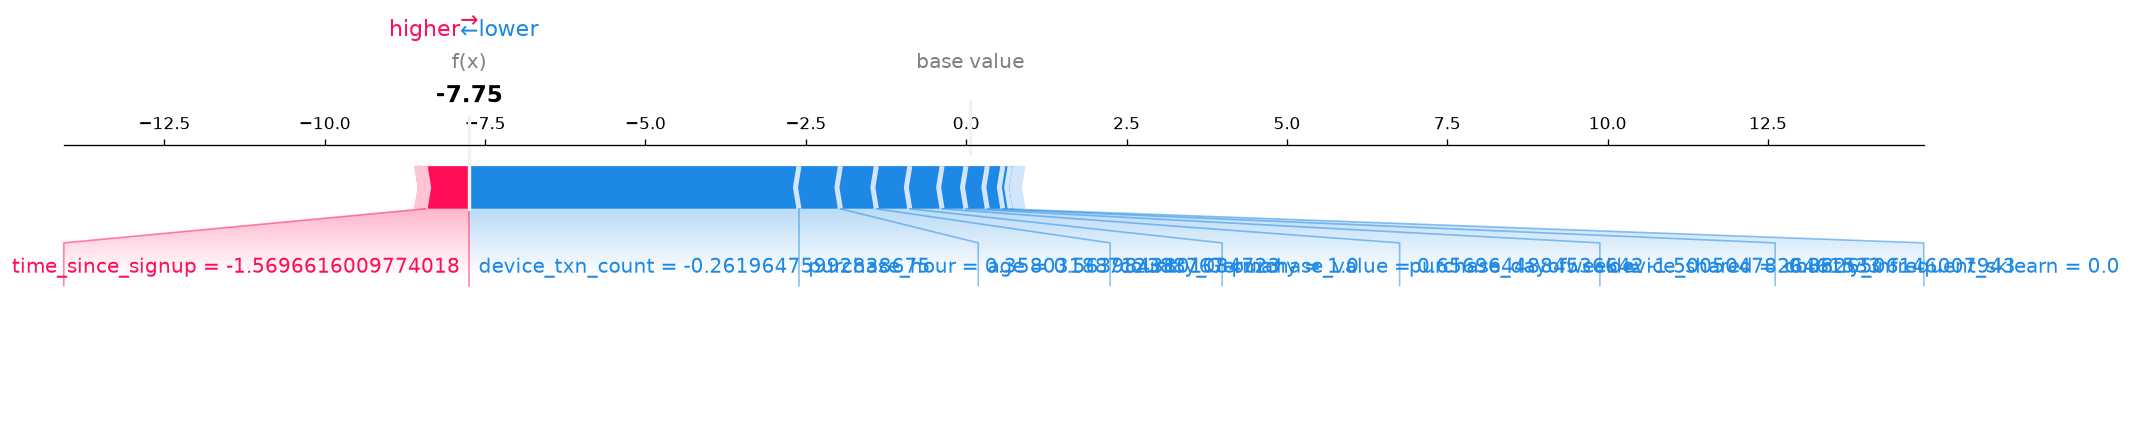

In [6]:
print(res_ec.examples)
for kind in ("true_positive", "false_positive", "false_negative"):
    print(f"\n{kind}")
    display(Image(filename=str(FIG / f"shap_force_ecommerce_{kind}.png")))

### 2.4 SHAP vs built-in importance

In [7]:
cmp_ec = (
    res_ec.builtin_top.assign(builtin_rank=lambda d: d.index + 1)
    .merge(
        res_ec.shap_top.assign(shap_rank=lambda d: d.index + 1),
        on="feature", how="outer",
    )
    .sort_values("shap_rank")
)
cmp_ec

,feature,importance,builtin_rank,mean_abs_shap,shap_rank
7,device_txn_count,0.555106,1.0,1.121789,1.0
14,time_since_signup,0.038157,2.0,0.673121,2.0
10,purchase_value,NaN,NaN,0.172455,3.0
0,age,NaN,NaN,0.140674,4.0
9,purchase_hour,NaN,NaN,0.127538,5.0
8,purchase_dayofweek,NaN,NaN,0.082605,6.0
12,source_Direct,0.017115,3.0,0.039944,7.0
1,browser_Chrome,0.014646,6.0,0.033783,8.0
11,sex_F,NaN,NaN,0.031462,9.0
13,source_SEO,0.014286,10.0,0.031333,10.0


## 3. Credit-card model (`creditcard`)

Extreme imbalance (~0.17% fraud); features are anonymised PCA components
(`V1`–`V28`) plus `Amount` and `Time`.

In [8]:
res_cc = explainability.explain_dataset(
    cc, target="Class",
    model_path=MODELS / "xgb_creditcard.joblib", name="creditcard",
)


creditcard


Saved -> reports/figures/importance_builtin_creditcard.png

Built-in importance (top 10):
feature  importance
    V14    0.461322
    V12    0.128390
     V4    0.058447
    V10    0.049561
     V3    0.031389
     V8    0.030858
    V19    0.020960
    V17    0.020301
    V18    0.016261
    V20    0.014855


Saved -> reports/figures/shap_summary_creditcard.png


Saved -> reports/figures/shap_bar_creditcard.png

SHAP importance (top 10, mean |SHAP|):
feature  mean_abs_shap
    V14       2.907090
     V4       1.999204
    V12       1.442366
    V10       0.972705
     V3       0.959847
    V11       0.934174
     V8       0.581401
    V19       0.551434
 Amount       0.429080
     V1       0.426978


Saved -> reports/figures/shap_force_creditcard_true_positive.png


Saved -> reports/figures/shap_force_creditcard_false_positive.png


Saved -> reports/figures/shap_force_creditcard_false_negative.png

Explained individual predictions:
    true_positive: prob=1.0000 (true=1, pred=1)
   false_positive: prob=1.0000 (true=0, pred=1)
   false_negative: prob=0.0000 (true=1, pred=0)


,feature,importance
0,V14,0.461322
1,V12,0.128390
2,V4,0.058447
3,V10,0.049561
4,V3,0.031389
5,V8,0.030858
6,V19,0.020960
7,V17,0.020301
8,V18,0.016261
9,V20,0.014855


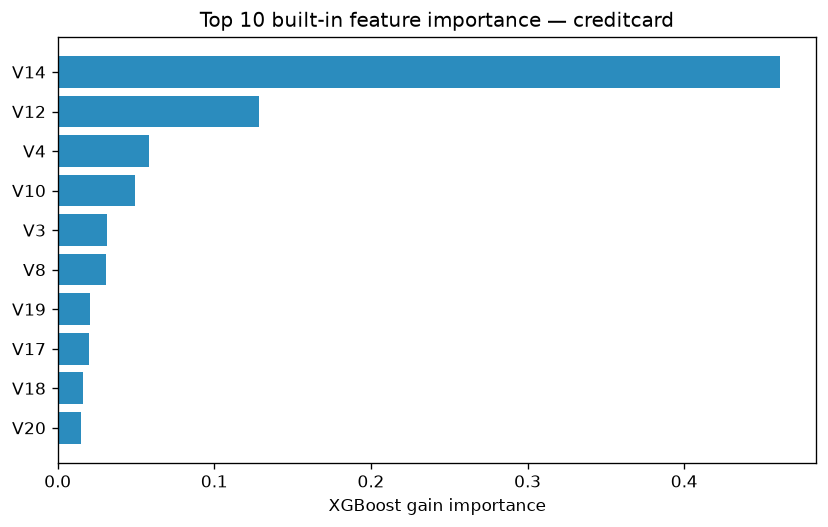

In [9]:
display(res_cc.builtin_top)
display(Image(filename=str(FIG / "importance_builtin_creditcard.png")))

,feature,mean_abs_shap
0,V14,2.907090
1,V4,1.999204
2,V12,1.442366
3,V10,0.972705
4,V3,0.959847
5,V11,0.934174
6,V8,0.581401
7,V19,0.551434
8,Amount,0.429080
9,V1,0.426978


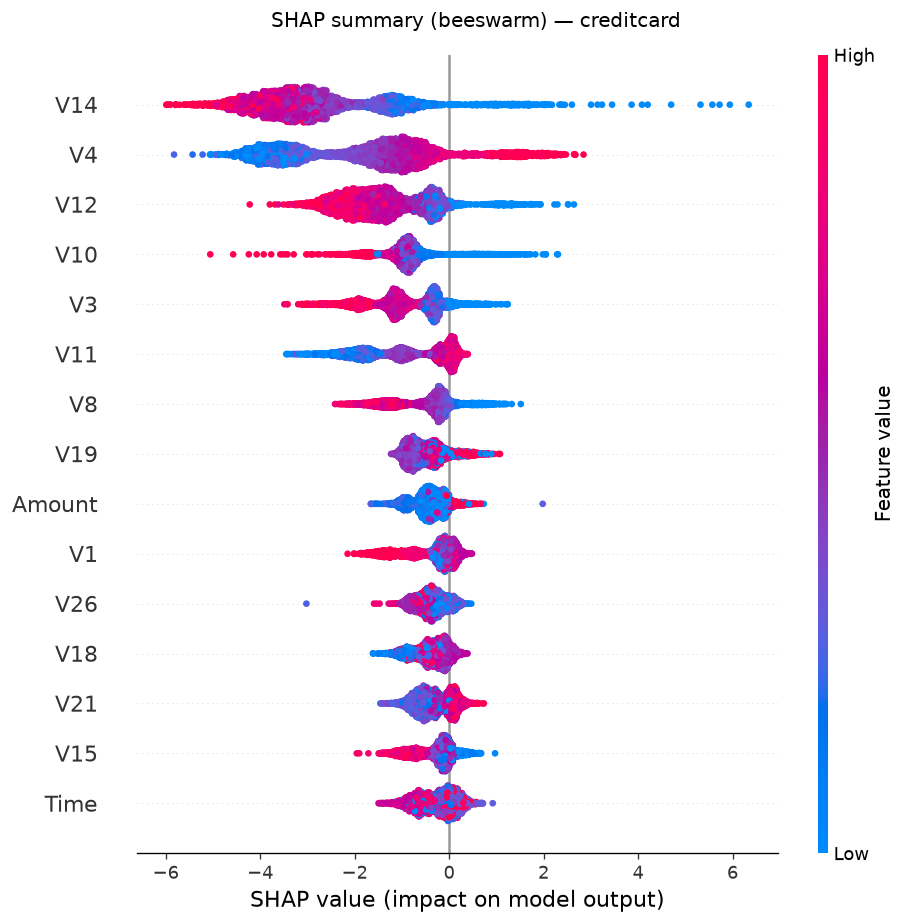

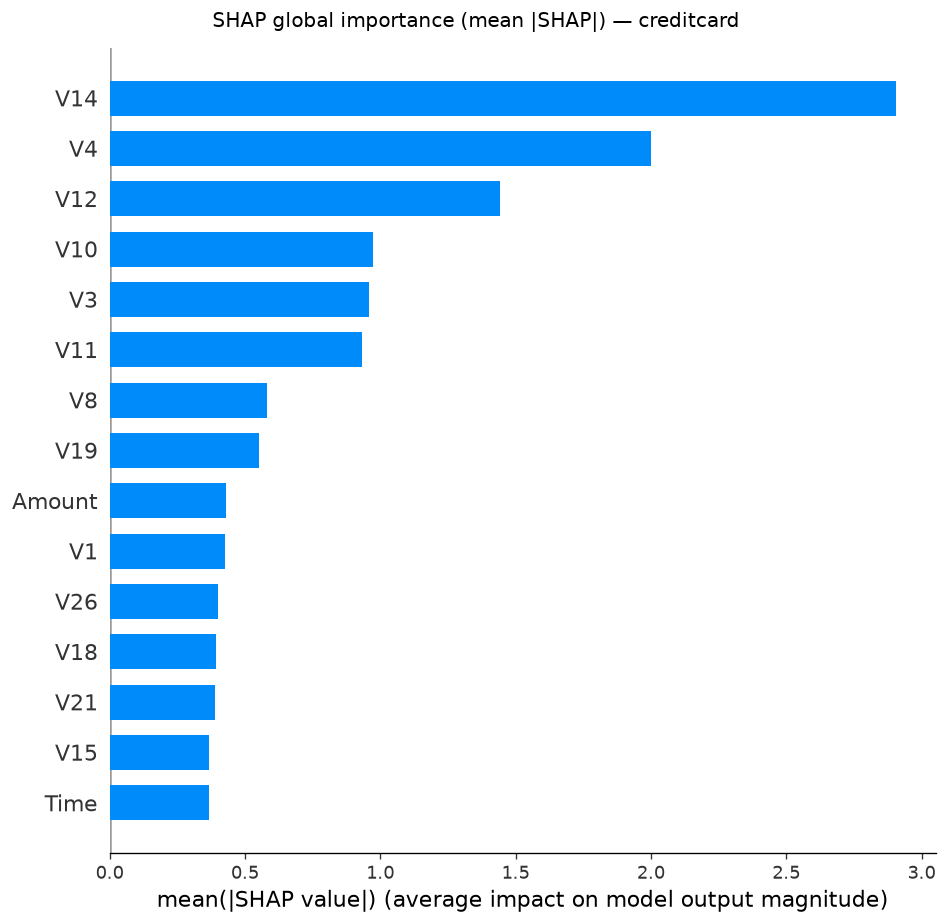

In [10]:
display(res_cc.shap_top)
display(Image(filename=str(FIG / "shap_summary_creditcard.png")))
display(Image(filename=str(FIG / "shap_bar_creditcard.png")))

{'true_positive': {'true_label': 1, 'pred_label': 1, 'fraud_probability': 0.9999998807907104}, 'false_positive': {'true_label': 0, 'pred_label': 1, 'fraud_probability': 0.9999969005584717}, 'false_negative': {'true_label': 1, 'pred_label': 0, 'fraud_probability': 3.1378755238620215e-07}}

true_positive


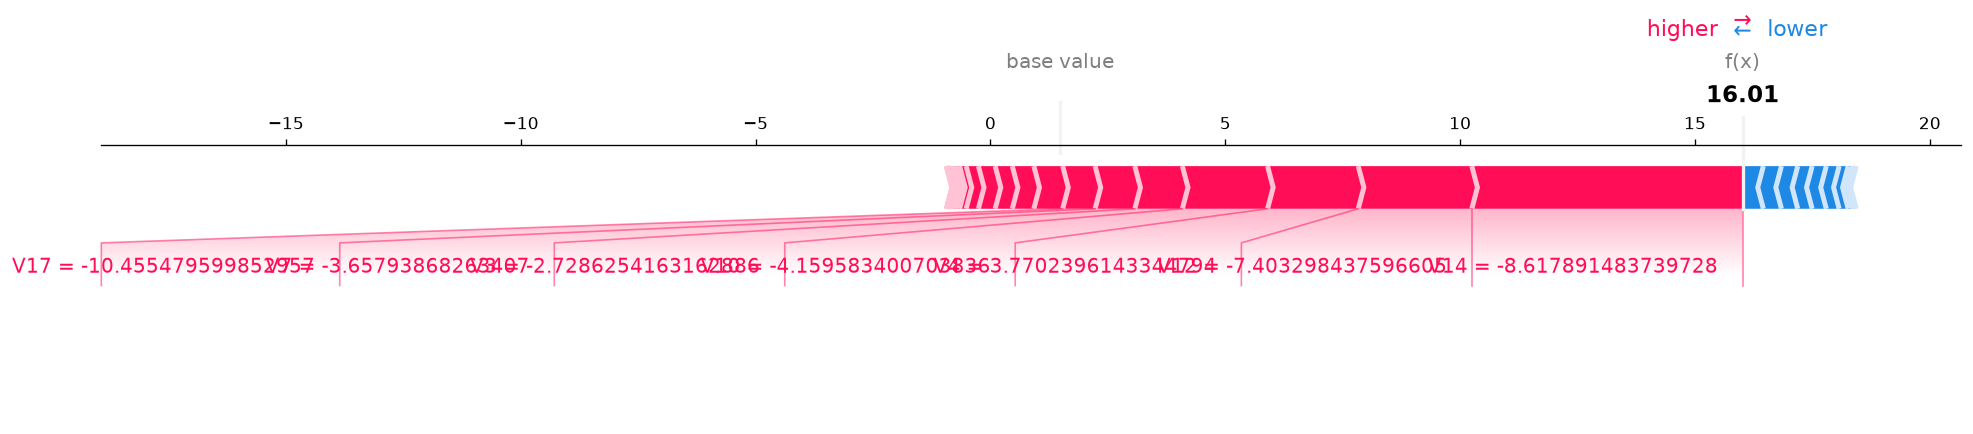


false_positive


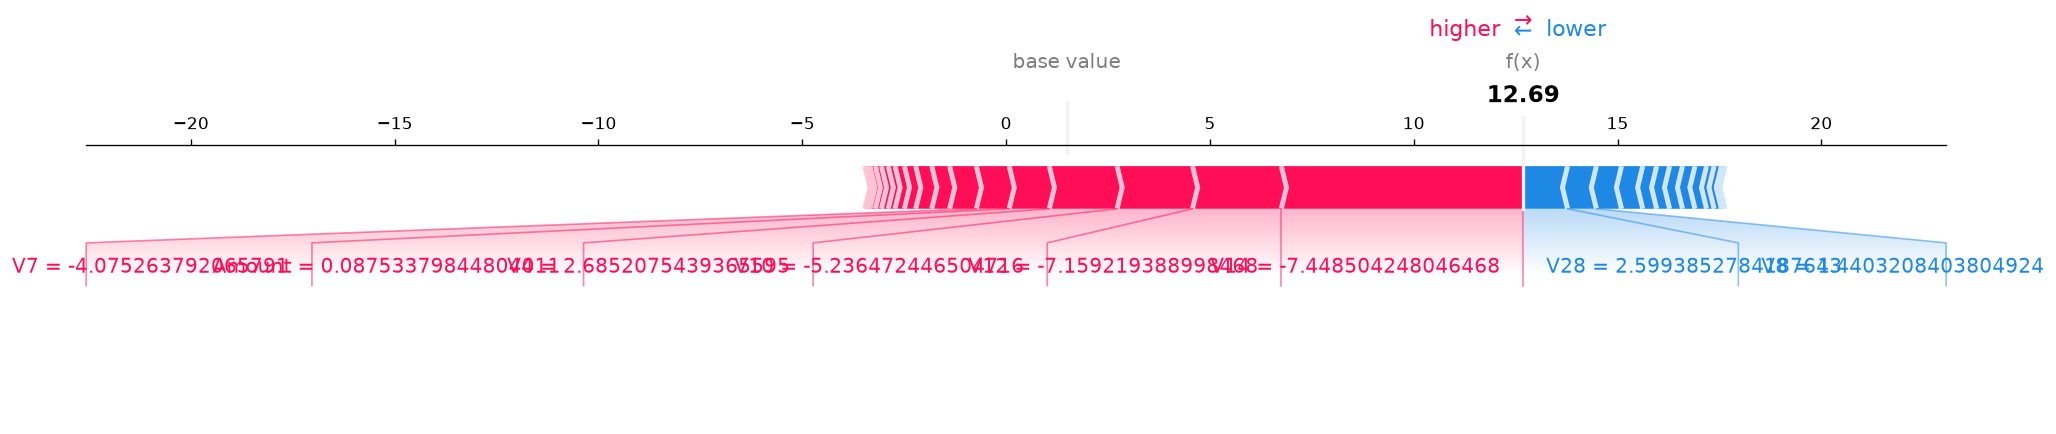


false_negative


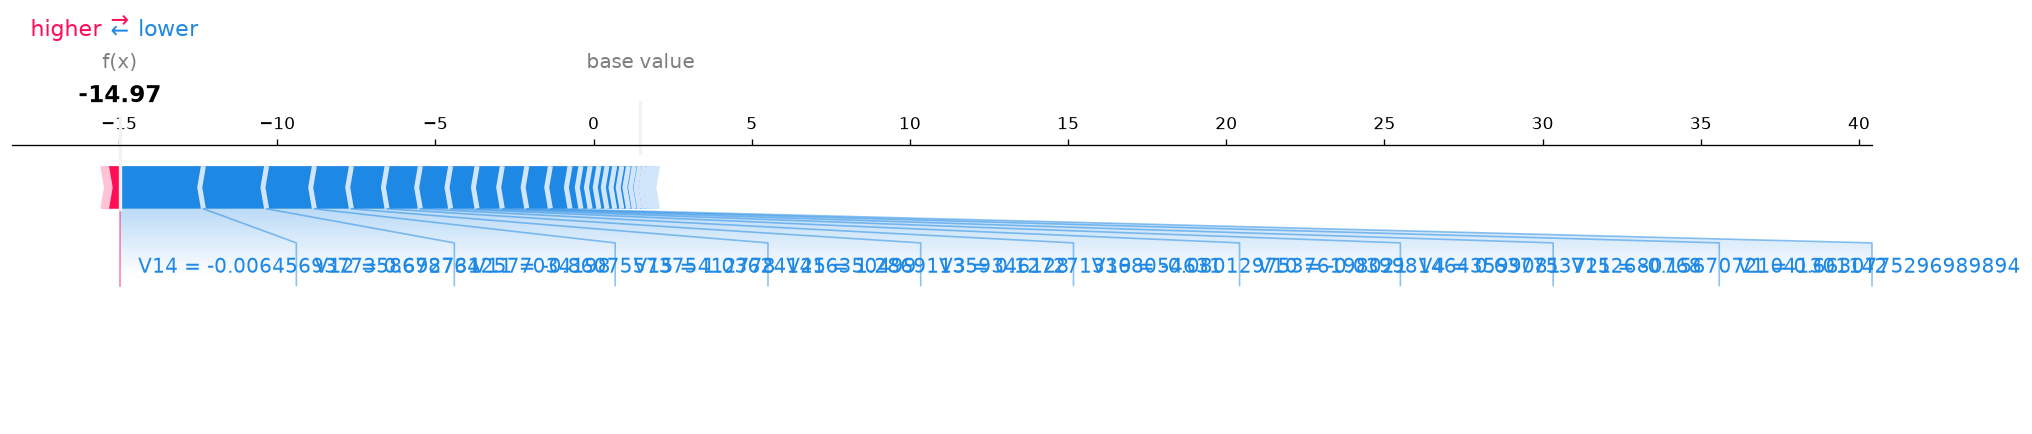

In [11]:
print(res_cc.examples)
for kind in ("true_positive", "false_positive", "false_negative"):
    print(f"\n{kind}")
    display(Image(filename=str(FIG / f"shap_force_creditcard_{kind}.png")))

In [12]:
cmp_cc = (
    res_cc.builtin_top.assign(builtin_rank=lambda d: d.index + 1)
    .merge(
        res_cc.shap_top.assign(shap_rank=lambda d: d.index + 1),
        on="feature", how="outer",
    )
    .sort_values("shap_rank")
)
cmp_cc

,feature,importance,builtin_rank,mean_abs_shap,shap_rank
5,V14,0.461322,1.0,2.907090,1.0
11,V4,0.058447,3.0,1.999204,2.0
4,V12,0.128390,2.0,1.442366,3.0
2,V10,0.049561,4.0,0.972705,4.0
10,V3,0.031389,5.0,0.959847,5.0
3,V11,NaN,NaN,0.934174,6.0
12,V8,0.030858,6.0,0.581401,7.0
8,V19,0.020960,7.0,0.551434,8.0
0,Amount,NaN,NaN,0.429080,9.0
1,V1,NaN,NaN,0.426978,10.0


## 4. Interpretation & business recommendations

The full written interpretation — top-5 fraud drivers, SHAP-vs-built-in
comparison, surprising findings, and the actionable recommendations — is in
[`reports/interim_3_report.md`](../reports/interim_3_report.md) and the
end-to-end narrative in [`reports/final_report.md`](../reports/final_report.md).

**Headline drivers**

- **E-commerce:** `device_txn_count` (shared devices) and `time_since_signup`
  (purchases moments after signup) dominate both rankings.
- **Credit card:** the anonymised components `V14`, `V4`, `V12`, `V10`, `V3`
  carry almost all the signal.

**Recommendations (see report for the SHAP evidence behind each):**

1. Step-up verification for purchases made within a short window of signup.
2. Flag / rate-limit devices shared across many accounts.
3. Deploy a real-time `V14/V12/V10`-style anomaly score for card transactions
   and route high-SHAP cases to manual review.